In [1]:
#Import Libraries
import os
import json
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
#Dataset Paths
base_dir = r"C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\astro_dataset_maxia\astro_dataset_maxia"

train_dir = os.path.join(base_dir, "training")
val_dir   = os.path.join(base_dir, "validation")
test_dir  = os.path.join(base_dir, "test")

print(train_dir)
print(val_dir)
print(test_dir)

C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\astro_dataset_maxia\astro_dataset_maxia\training
C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\astro_dataset_maxia\astro_dataset_maxia\validation
C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\astro_dataset_maxia\astro_dataset_maxia\test


In [3]:
#Image Parameters
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 30

In [4]:
#Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,

    shear_range=0.1,
    zoom_range=0.1,

    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [9]:
# Load Dataset

train_generator = train_datagen.flow_from_directory(

    r"C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\astro_dataset_maxia\training",

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="categorical"

)


val_generator = val_datagen.flow_from_directory(

    r"C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\astro_dataset_maxia\validation",

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="categorical"

)


test_generator = test_datagen.flow_from_directory(

    r"C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\astro_dataset_maxia\test",

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False

)

Found 2416 images belonging to 12 classes.
Found 658 images belonging to 12 classes.
Found 345 images belonging to 12 classes.


In [10]:
#Verify Dataset
print("Train Samples:", train_generator.samples)
print("Validation Samples:", val_generator.samples)
print("Test Samples:", test_generator.samples)

print("\nClass Indices:")
print(train_generator.class_indices)

Train Samples: 2416
Validation Samples: 658
Test Samples: 345

Class Indices:
{'asteroid': 0, 'black_hole': 1, 'earth': 2, 'galaxy': 3, 'jupiter': 4, 'mars': 5, 'mercury': 6, 'neptune': 7, 'pluto': 8, 'saturn': 9, 'uranus': 10, 'venus': 11}


In [11]:
#Save class names
class_names = list(train_generator.class_indices.keys())

with open("class_names.json", "w") as f:

    json.dump(class_names, f)

print("Class names saved.")

Class names saved.


In [12]:
#CNN Model Architecture
model = Sequential([

    Conv2D(32, (3,3),
           activation="relu",
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Conv2D(64, (3,3),
           activation="relu"),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Conv2D(128, (3,3),
           activation="relu"),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,
          activation="relu"),

    Dropout(0.5),

    Dense(12,
          activation="softmax")

])

c:\MSc.FY Projects\Stellar Object Prediction\objenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
#Compile Model
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,520,012 (24.87 MB)

 Trainable params: 6,519,564 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
#Callbacks
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=7,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=3,

    min_lr=0.00001

)

checkpoint = ModelCheckpoint(

    "best_model.h5",

    monitor="val_accuracy",

    save_best_only=True

)

In [15]:
#Train Model
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=EPOCHS,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ]

)

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.3991 - loss: 6.5941

76/76 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.4876 - loss: 4.5500 - val_accuracy: 0.0760 - val_loss: 19.5622 - learning_rate: 0.0010
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5650 - loss: 2.1364 - val_accuracy: 0.0729 - val_loss: 39.7016 - learning_rate: 0.0010
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.6275 - loss: 1.5189

76/76 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6175 - loss: 1.5508 - val_accuracy: 0.2994 - val_loss: 6.8463 - learning_rate: 0.0010
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.6051 - loss: 1.4110

76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6126 - loss: 1.4001 - val_accuracy: 0.3131 - val_loss: 10.2974 - learning_rate: 0.0010
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.6321 - loss: 1.3506

76/76 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6457 - loss: 1.2023 - val_accuracy: 0.4772 - val_loss: 2.2265 - learning_rate: 0.0010
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.6675 - loss: 1.1279

...

76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8262 - loss: 0.4795 - val_accuracy: 0.8921 - val_loss: 0.3855 - learning_rate: 3.0000e-04
Epoch 18/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 976ms/step - accuracy: 0.8520 - loss: 0.4524

76/76 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8423 - loss: 0.4591 - val_accuracy: 0.8997 - val_loss: 0.3399 - learning_rate: 3.0000e-04
Epoch 19/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8506 - loss: 0.4360 - val_accuracy: 0.8571 - val_loss: 0.4529 - learning_rate: 3.0000e-04
Epoch 20/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8485 - loss: 0.4515 - val_accuracy: 0.8845 - val_loss: 0.4189 - learning_rate: 3.0000e-04
Epoch 21/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8485 - loss: 0.4485 - val_accuracy: 0.8693 - val_loss: 0.3699 - learning_rate: 3.0000e-04
Epoch 22/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8605 - loss: 0.3897 - val_accuracy: 0.8936 - val_loss: 0.3381 - learning_rate: 9.0000e-05
Epoch 23/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8601 - loss: 0.3764 - val_accuracy: 0.8708 - val_loss: 0.4121 - learning_rate: 9.0000e-05
Epoch 24/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 978ms/step - accuracy: 0.8658 - loss: 0.

76/76 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8779 - loss: 0.3543 - val_accuracy: 0.9012 - val_loss: 0.3440 - learning_rate: 9.0000e-05
Epoch 25/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.8752 - loss: 0.3266

76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8729 - loss: 0.3397 - val_accuracy: 0.9027 - val_loss: 0.3383 - learning_rate: 9.0000e-05
Epoch 26/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8808 - loss: 0.3537 - val_accuracy: 0.9027 - val_loss: 0.3435 - learning_rate: 2.7000e-05
Epoch 27/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 966ms/step - accuracy: 0.8605 - loss: 0.3895

76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8820 - loss: 0.3364 - val_accuracy: 0.9073 - val_loss: 0.3182 - learning_rate: 2.7000e-05
Epoch 28/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8816 - loss: 0.3237 - val_accuracy: 0.9027 - val_loss: 0.3375 - learning_rate: 2.7000e-05
Epoch 29/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8787 - loss: 0.3494 - val_accuracy: 0.9012 - val_loss: 0.3273 - learning_rate: 2.7000e-05
Epoch 30/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8916 - loss: 0.3195 - val_accuracy: 0.9073 - val_loss: 0.3369 - learning_rate: 2.7000e-05


In [16]:
#Save Final Model
model.save("cnn_model.h5")

print("Model Saved.")

Model Saved.


In [17]:
#Evaluate Model
test_loss, test_acc = model.evaluate(

    test_generator

)

print("\nTest Accuracy:", test_acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.9275 - loss: 0.2481

Test Accuracy: 0.9275362491607666


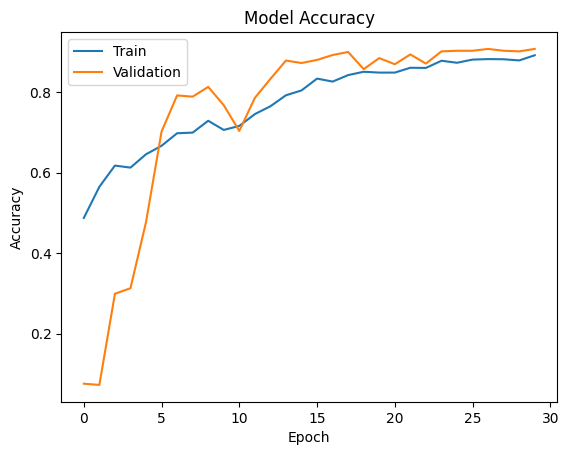

In [18]:
#Plot Graph Accuracy
plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")

plt.ylabel("Accuracy")

plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

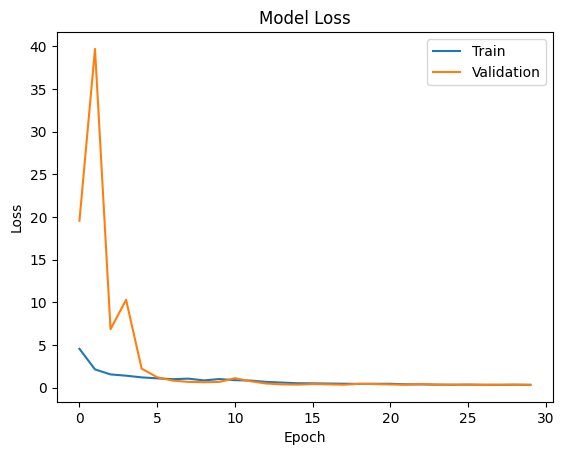

In [19]:
#Plot Loss Graph
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Model Loss")

plt.ylabel("Loss")

plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()